**Overview of BERT**

BERT stands for Bidirectional Encoder Representations from Transformers.
In this notebook, we will walk through implementation of BERT for a simple classificaiton problem and compare it with traditional Machine Learning and Neural Network approaches.



In [ ]:
#Import the necessary Libraries

In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


!pip install -q tensorflow_text graphviz
import tensorflow_text as text
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.utils import plot_model


Load the dataset.
The dataset is a spam classifier dataset available on https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset


In [ ]:
df = pd.read_csv('spam.csv')
df.head()



,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Split dataset into training and testing set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, stratify = df.label, random_state=42)

Start to build BERT model.
We import Keras layer to preprocess and encode text for BERT. This returns a pre-trained BERT model.
This pre-trained model is used as an input to our neural Network based classifier.

##***Model Details***

This SavedModel implements the encoder API for text embeddings with transformer encoders. It expects a dict with three int32 Tensors as input: input_word_ids, input_mask, and input_type_ids.

The separate preprocessor SavedModels transform plain text inputs into this format, as described below.

This SavedModel is a companion of BERT models to preprocess plain text inputs into the input format expected by BERT. Check the encoder model documentation to find the correct preprocessing model for each particular encoder.

BERT has mainly 2 models, BERT Base and BERT Large.




| Model | #Params | Language | Dimentions |
| --- | --- | --- | --- |
| bert-base-uncased | 110M | English | BERT Base has 12 Layers, hidden size of 768 and 12 Attention Heads |
| bert-large-uncased | 340M | English | BERT Large has 24 Layers, hidden size of 1024 and 16 Attention Heads |
| bert-base-cased | 110M | English | BERT Base has 12 Layers, hidden size of 768 and 12 Attention Heads |
| bert-large-cased | 340M | English | BERT Large has 24 Layers, hidden size of 1024 and 16 Attention Heads |

In [ ]:
#Import Keras Layer of BERT preprocessor and encoder.

text_input = keras.layers.Input(shape=(), dtype=tf.string)
preprocessor = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
encoder_inputs = preprocessor(text_input)
encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4",
    trainable=False)
outputs = encoder(encoder_inputs)
pooled_output = outputs["pooled_output"]      # [batch_size, 768].
sequence_output = outputs["sequence_output"]  # [batch_size, seq_length, 768].

s = keras.layers.Dropout(0.1,name ='dropout')(pooled_output)
s = keras.layers.Dense(64,activation ='relu',name = 'h64')(s)
s = keras.layers.Dense(32,activation ='relu',name ='h34')(s)
s = keras.layers.Dense(8,activation ='relu',name ='h8')(s)
s = keras.layers.Dense(1,activation ='sigmoid',name ='output')(s)
model=keras.Model(inputs = [text_input],outputs = [s])

**Compile and Train the model**

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 keras_layer_2 (KerasLayer)  {'input_type_ids': (None,    0         ['input_2[0][0]']             
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

**Compile and Train the Model**

In [ ]:
model.fit(X_train, y_train, epochs=3)

Epoch 1/3
140/140 [==============================] - 57s 305ms/step - loss: 0.2581 - accuracy: 0.8907
Epoch 2/3
140/140 [==============================] - 46s 331ms/step - loss: 0.1326 - accuracy: 0.9527
Epoch 3/3
140/140 [==============================] - 45s 318ms/step - loss: 0.0963 - accuracy: 0.9666


**Get Predictions on test dataset**

In [ ]:
y_predict = model.predict(X_test)
y_pred = np.where(y_predict > 0.5,1,0)



35/35 [==============================] - 11s 313ms/step


In [ ]:
#Evaluate the model
eval = model.evaluate(X_test, y_test)
print(f'Loss : {eval[0]}')
print(f'Accuracy : {eval[1]}')

35/35 [==============================] - 12s 333ms/step - loss: 0.0654 - accuracy: 0.9812
Loss : 0.06543650478124619
Accuracy : 0.9811659455299377


**Compute and Print classification report**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
classification_report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:\n", classification_report)
#precision, recall, and accuracy scores look good



Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



**Plot Confusion matrix of predictions**

Confusion Matrix:
 [[960   6]
 [ 15 134]]


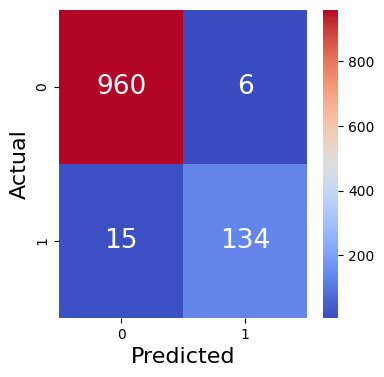

In [ ]:

cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)
#report=classification_report(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm,annot=True,cmap='coolwarm',xticklabels=[0,1],fmt='d',annot_kws={"fontsize":19})
plt.title("Confusion Matrix from BERT")
plt.xlabel("Predicted",fontsize=16)
plt.ylabel("Actual",fontsize=16)
plt.show()


# Machine Learning Approach

Fit the same data using traditional approaches, like Logistic Regression

In [ ]:
#ML Approach

We will use Tf-Idf vectorizer and fit the data on a Logistic Regression model. The idea is to set a baseline for the spam dataset and compare the results with BERT.

In [ ]:
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    stop_words='english',
    ngram_range=(1, 3),
    max_features=10000
)

word_vectorizer.fit(df['text'])

tfidf_train = word_vectorizer.transform(X_train)
tfidf_test = word_vectorizer.transform(X_test)

In [ ]:
def metrics(model,x,y):
    y_pred = model.predict(x)
    acc = accuracy_score(y, y_pred)
    f1=f1_score(y, y_pred)
    cm=confusion_matrix(y, y_pred)
    #report=classification_report(y,y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm,annot=True,cmap='coolwarm',xticklabels=[0,1],fmt='d',annot_kws={"fontsize":19})
    plt.title("Confusion Matrix from Logistic Regression Model")
    plt.xlabel("Predicted",fontsize=16)
    plt.ylabel("Actual",fontsize=16)
    plt.show()
    #print("\nAccuracy: ",round(acc,2))
    #print("\nF1 Score: ",round(f1,2))
#     print("\nConfusion Matrix: \n",cm)
    #print("\nReport:",report)



Fit the training data in the Classifier model

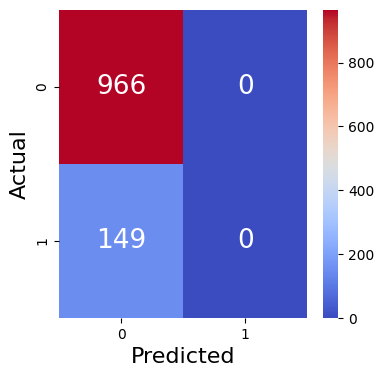


Accuracy:  0.87

F1 Score:  0.0


In [ ]:
# Logistic Regression with TF-IDF
classifier = LogisticRegression(C=0.1, solver='sag')
classifier.fit(tfidf_train, y_train)
metrics(classifier,tfidf_test,y_test)

In [ ]:
from sklearn.metrics import classification_report
pred = classifier.predict(tfidf_test)
#classification_report(y_test,pred)
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93      1115
           1       0.00      0.00      0.00         0

    accuracy                           0.87      1115
   macro avg       0.50      0.43      0.46      1115
weighted avg       1.00      0.87      0.93      1115



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Neural network approach using GloVe Embeddings

Pre-Trained GloVe embeddings will be used and same spam dataset will be trained on a feed forward neural network with the same architecture as was used for training BERT.

This is to illustrate the output differences between static embeddings like GloVe and contextual embeddings like BERT.

GloVe 6B model with 300 dimentions will be used in this case.


In [ ]:
!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip -q glove.6B.zip


--2025-02-19 07:07:20--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.05MB/s    in 2m 40s  

2025-02-19 07:10:01 (5.13 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



In [ ]:
!pip install -q keras_preprocessing
from tqdm import tqdm
import pandas as pd
from sklearn.model_selection import train_test_split
from keras_preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dense,Embedding,Flatten
from tensorflow.keras.models import Sequential
from keras_preprocessing.sequence import pad_sequences


from sklearn.metrics import classification_report, confusion_matrix


Read the dataset and create a Pandas dataframe

In [ ]:
df = pd.read_csv('spam.csv')
df.head()


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Preprocess the data.
Tokenize the sentences, create a vocublary and pad the text sequences

In [ ]:

# prepare tokenizer
t = Tokenizer()
t.fit_on_texts(df['text'].values)
vocab_size = len(t.word_index) + 1
# integer encode the documents
encoded_docs = t.texts_to_sequences(df['text'].values)
print(vocab_size)
# pad documents to a max length of 4 words
MAX_SEQUENCE_LENGTH = 20
padded_docs = pad_sequences(encoded_docs, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
print(len(padded_docs))

8921
5572


Load GloVe embedding vectors

In [ ]:
embeddings_index = dict()
f = open('glove.6B.300d.txt',mode='rt',encoding='utf-8')

for line in f:
    values = line.split()
    words = values[0]
    coefs = np.asarray(values[1:],dtype='float32')
    embeddings_index[words] = coefs
f.close()
print('Loaded word vectors',len(embeddings_index)) #Loaded word vectors 400000

Loaded word vectors 400000


Translate each word from the vocublary into a 300 dimension Vector suing pre-trained GloVe embeddings.

In [ ]:
EMBEDDING_DIM=300
# create a weight matrix for words in training docs
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in t.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

print(embedding_matrix.shape)

(8921, 300)


Build a similar feed forward neural network with similar architecture as was used during BERT training.

Embeddings layer in this case will be pre-initilized with the embedding vector created using GloVe

In [ ]:
model3 = Sequential()
model3.add(Embedding(vocab_size,EMBEDDING_DIM,weights = [embedding_matrix],trainable = False))
model3.add(Flatten())
model3.add(Dense(64,activation = 'relu'))
model3.add(Dense(32,activation = 'relu'))
model3.add(Dense(8,activation = 'relu'))
model3.add(Dense(1,activation = 'sigmoid'))
model3.compile(optimizer='adam',loss='binary_crossentropy',metrics = ['accuracy'])
#history = model3.fit(pad_seq,y,epochs = 5,batch_size=256,validation_split=0.2)

In [ ]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │       2,676,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,676,300 (10.21 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,676,300 (10.21 MB)

In [ ]:

# split dataset into train and test
labels=df['label'].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(padded_docs, labels, test_size=0.2, random_state=42)



In [ ]:
# fit the model and train it for 3 epochs
model3.fit(X_train, y_train, epochs=3)


Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8854 - loss: 0.2794
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9877 - loss: 0.0387
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9970 - loss: 0.0093


In [ ]:
# evaluate the model
loss, accuracy = model3.evaluate(X_test, y_test, verbose=0)
print('Accuracy: %f' % (accuracy*100))

Accuracy: 97.399104


In [ ]:
pred = model3.predict(X_test)
y_pred = np.where(pred > 0.5,1,0)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
#Calculate classification report from the trained model

from sklearn.metrics import classification_report, confusion_matrix

classification_report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:\n", classification_report)
#precision, recall, and accuracy scores look good



Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.94      0.87      0.90       150

    accuracy                           0.97      1115
   macro avg       0.96      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



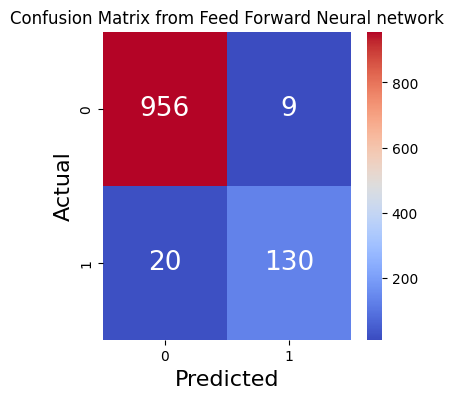

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
#print("Confusion Matrix:\n", cm)
#report=classification_report(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm,annot=True,cmap='coolwarm',xticklabels=[0,1],fmt='d',annot_kws={"fontsize":19})
plt.title("Confusion Matrix from Feed Forward Neural network")
plt.xlabel("Predicted",fontsize=16)
plt.ylabel("Actual",fontsize=16)
plt.show()
